In [26]:
!nvidia-smi

Tue Aug 18 12:48:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 592.82                 Driver Version: 592.82         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P3              7W /   30W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import urllib.request

url = "https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip"
urllib.request.urlretrieve(url, "fruits.zip")


('fruits.zip', <http.client.HTTPMessage at 0x2d46c207070>)

In [6]:
!unzip 'D:\ABHI-VSCODE\CNN-Multi Class Classification\fruits.zip'

Archive:  D:\ABHI-VSCODE\CNN-Multi Class Classification\fruits.zip
   creating: fruits/
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen 

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [8]:
tf.__version__

'2.21.0'

# image dataset flow from directory

In [10]:
img_height,img_width =32,32
batch_size =20

train_ds =tf.keras.utils.image_dataset_from_directory(
    r"D:\ABHI-VSCODE\CNN-Multi Class Classification\fruits\train",
    image_size=(img_height,img_width),
    batch_size=batch_size
)
test_ds =tf.keras.utils.image_dataset_from_directory(
    r"D:\ABHI-VSCODE\CNN-Multi Class Classification\fruits\test",
    image_size=(img_height,img_width),
    batch_size=batch_size
)
val_ds =tf.keras.utils.image_dataset_from_directory(
    r"D:\ABHI-VSCODE\CNN-Multi Class Classification\fruits\validation",
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 460 files belonging to 3 classes.
Found 130 files belonging to 3 classes.
Found 66 files belonging to 3 classes.


# our machine not recorzinege image it understand by lable and title

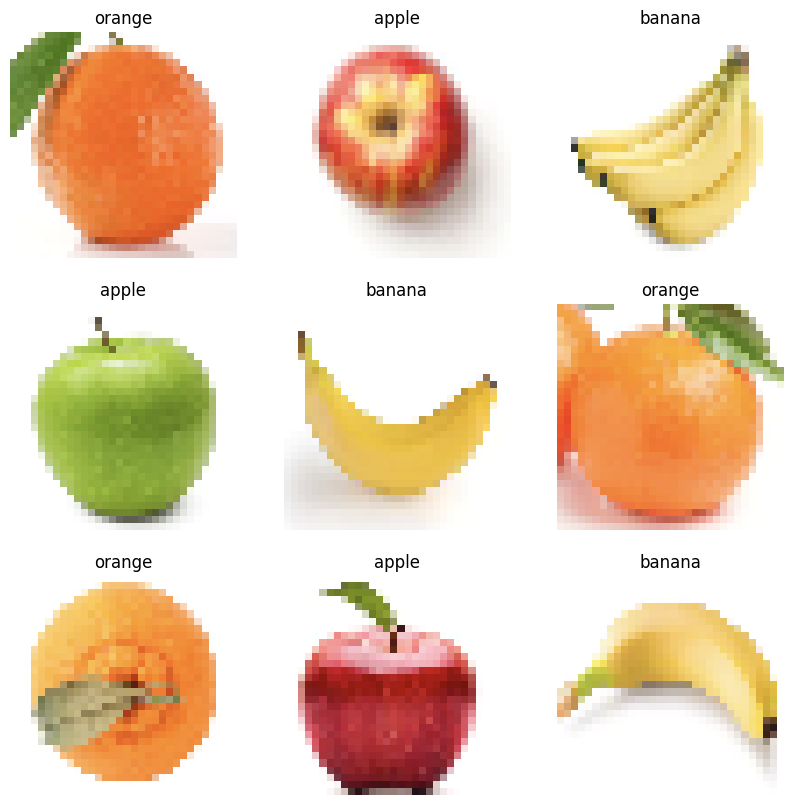

In [11]:
class_names =['apple','banana','orange']
plt.figure(figsize=(10,10))

for images,labels in train_ds.take(1):
  for i in range(9):
    ax =plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_names[labels[i]])
    plt.axis('off')

In [12]:
model =tf.keras.Sequential(
    [
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128,activation='relu'),
        tf.keras.layers.Dense(3)
    ]
)

In [13]:
model.compile(
    optimizer='rmsprop',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [14]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=21
)

Epoch 1/21
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.4957 - loss: 0.9921 - val_accuracy: 0.6667 - val_loss: 0.8003
Epoch 2/21
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7152 - loss: 0.7095 - val_accuracy: 0.8030 - val_loss: 0.5124
Epoch 3/21
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8022 - loss: 0.4921 - val_accuracy: 0.6818 - val_loss: 0.6404
Epoch 4/21
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8609 - loss: 0.3667 - val_accuracy: 0.8636 - val_loss: 0.3253
Epoch 5/21
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8870 - loss: 0.3176 - val_accuracy: 0.8788 - val_loss: 0.2967
Epoch 6/21
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8957 - loss: 0.2705 - val_accuracy: 0.8788 - val_loss: 0.3381
Epoch 7/21
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9370 - loss: 0.1919 - val_accuracy: 0.8788 - val_loss: 0.3357
Epoch 8/21
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9239 - loss: 0.1973 - val_accuracy: 0.9091 - 

In [15]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9615 - loss: 0.1543


[0.15429285168647766, 0.9615384340286255]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


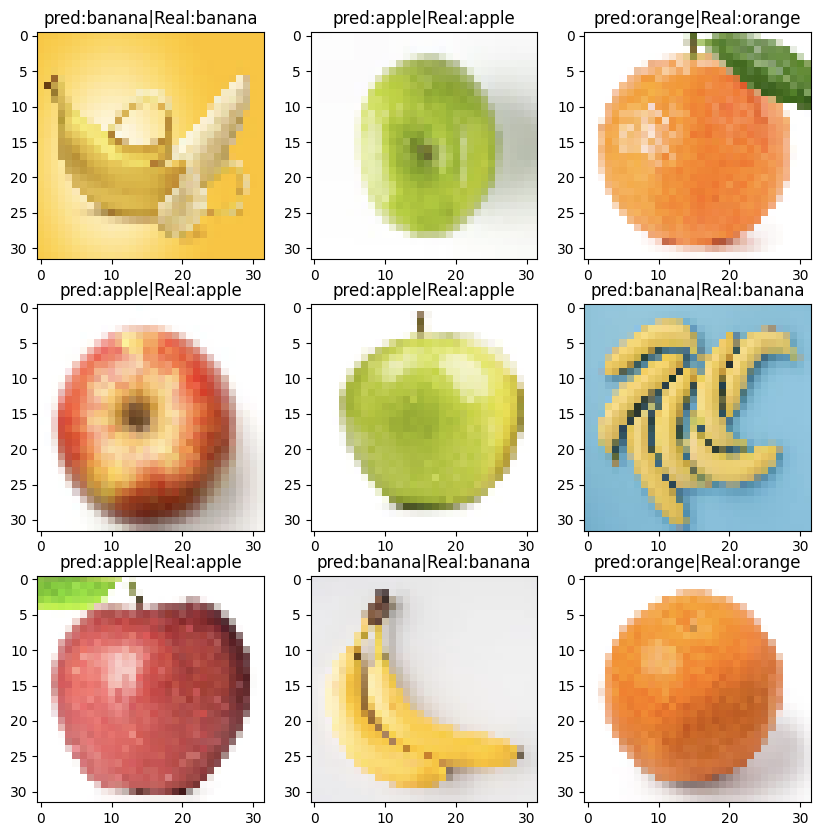

In [21]:
import numpy

plt.figure(figsize=(10,10))
for images,labels in test_ds.take(1):
  predictions =model.predict(images)
  #print(classification)

  for i in range(9):
    ax =plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    index =numpy.argmax(predictions[i])
    plt.title('pred:' + class_names[index] +"|Real:" + class_names[labels[i]])

# ml model -- save the model using pickle
         --if you work image model -- how do you save -- h5.file (hadoop extension file)

In [22]:
converter =tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model =converter.convert()

with open('model.tflite','wb') as f:
  f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\abhis\AppData\Local\Temp\tmpltgb_w2q\assets


INFO:tensorflow:Assets written to: C:\Users\abhis\AppData\Local\Temp\tmpltgb_w2q\assets


Saved artifact at 'C:\Users\abhis\AppData\Local\Temp\tmpltgb_w2q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  3110246089472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3110246095632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3110246104784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3110246420672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3110246426656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3110246428240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3110246091056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3110252284736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3110246426480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3110252292480: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [25]:
import tensorflow as tf
print(tf.__version__)


2.21.0
